<a href="https://colab.research.google.com/github/developer-AJabbar/Machine-Learning-Models/blob/main/House_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [19]:
df = pd.read_csv('/content/House_Price.csv')
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [43]:
df['Price'].describe()


,Price
count,2000.000000
mean,537676.855000
std,276428.845719
min,50005.000000
25%,300098.000000
50%,539254.000000
75%,780086.000000
max,999656.000000


In [20]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [21]:
X = df.drop(['Id', 'Price'], axis=1)
y = df['Price']


In [31]:
categorical_features = ['Location', 'Condition', 'Garage']
numerical_features = [
    'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt'
]


In [32]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)


In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])


In [36]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Location', 'Condition',
                                                   'Garage']),
                                                 ('num', 'passthrough',
                                                  ['Area', 'Bedrooms',
                                                   'Bathrooms', 'Floors',
                                                   'YearBuilt'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 252229.64345000003
RMSE: 292030.6412764076
R2 Score: -0.0961848278023425


In [39]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline, X, y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())


CV R2 Scores: [-0.05813484 -0.0971145  -0.06293922 -0.09714484 -0.04294134]
Average CV R2: -0.07165494688670285


In [40]:
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()
importances = pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)


,Feature,Importance
10,num__Area,0.315786
14,num__YearBuilt,0.257723
11,num__Bedrooms,0.088928
12,num__Bathrooms,0.067871
13,num__Floors,0.046615
1,cat__Location_Rural,0.025355
3,cat__Location_Urban,0.024349
0,cat__Location_Downtown,0.023668
7,cat__Condition_Poor,0.023435
5,cat__Condition_Fair,0.023425


In [41]:
new_house = pd.DataFrame([{
    'Area': 3000,
    'Bedrooms': 3,
    'Bathrooms': 2,
    'Floors': 2,
    'YearBuilt': 2015,
    'Location': 'Urban',
    'Condition': 'Good',
    'Garage': 'Yes'
}])

price = pipeline.predict(new_house)
print("Predicted Price:", price[0])


Predicted Price: 524284.27


In [42]:
new_house = pd.DataFrame([{
    'Area': 2800,
    'Bedrooms': 3,
    'Bathrooms': 2,
    'Floors': 2,
    'YearBuilt': 2018,
    'Location': 'Urban',
    'Condition': 'Good',
    'Garage': 'Yes'
}])

pipeline.predict(new_house)


array([503735.34666667])

In [44]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)


,Price
Price,1.000000
Floors,0.055890
YearBuilt,0.004845
Area,0.001542
Bedrooms,-0.003471
Bathrooms,-0.015737
Id,-0.025643


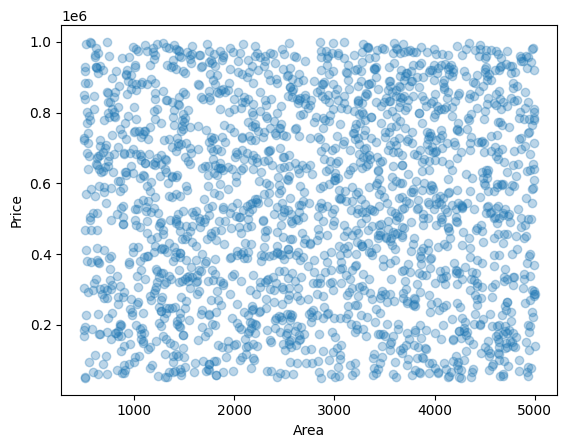

In [45]:
import matplotlib.pyplot as plt

plt.scatter(df['Area'], df['Price'], alpha=0.3)
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()


## **Suggested Note:**

Note on Model Performance:
The model was trained on the provided dataset to predict house prices. The evaluation metrics (MAE, RMSE, R²) indicate poor predictive performance. This is because the target variable (Price) in the dataset does not show a strong or consistent relationship with the input features (Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, Garage).
In other words, the dataset does not contain enough predictive signal for the model to learn meaningful patterns.
Despite this, the pipeline and model are implemented correctly and can be used with datasets that contain stronger feature–target relationships.